# 15 — Full Canonical Reproduction: 30 Seeds × 5 Horizons (Official Protocol)

**Purpose**: independently regenerate the full per-run dataset that Notebook 08 reports
(30 seeds, 5 horizons, Standalone LSTM vs ILT, `epochs=100, patience=20`), using
`canonical_pipeline.py` as the single source of truth, so the numbers behind Chapter 5's
H1/H2 claims come from a run YOU executed and can fully account for — not just inherited
text output from an earlier notebook.

### Important: this is a LONG run
30 seeds × 5 horizons × 2 models = 300 individual training runs. On the machine this was
prototyped on (1 CPU, no GPU) a single run took ~45-100s, so the full sweep took **~4.3
hours**. Your machine likely has more cores; wall-clock time will vary, but budget at least
a few hours and plan to let it run in the background (e.g. start it, go do something else,
come back later).

### Checkpointing / resume support
This notebook saves progress to `metrics/full_reproduction_checkpoint.pkl` **after every single
(horizon, seed) pair** (i.e. after both models are trained for that seed). If your kernel
crashes, your laptop sleeps, or you need to stop partway through, just re-run the notebook from
the top — it will detect what's already done and skip straight to the next unfinished
(horizon, seed) pair instead of starting over.

Run this AFTER `00_setup_canonical_baselines.ipynb` (needs `processed_data/canonical_data.pkl`).


In [1]:
import pickle, time, warnings, os, random
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from canonical_pipeline import (build_lstm_transformer, build_standalone_lstm,
                                 make_sequences, train_once, SEQ_LEN)
os.makedirs('metrics', exist_ok=True)

with open('processed_data/canonical_data.pkl', 'rb') as f:
    d = pickle.load(f)

HORIZONS = [1, 7, 14, 21, 28]
N_SEEDS = 30
# TRUE random draw, not a fixed formula -- every kernel run produces a DIFFERENT
# list of 30 seeds (Python's `random` module is seeded from OS entropy at
# interpreter start; nothing here is hardcoded or reproducible by design).
# Same approach now used in Notebook 08 and Notebook 12.
SEEDS = [42 + i*7 for i in range(N_SEEDS)]  # fixed documented seeds (42..245) -- reproducible
CHECKPOINT_PATH = 'metrics/full_reproduction_checkpoint.pkl'

print(f"Plan: {len(HORIZONS)} horizons x {N_SEEDS} seeds x 2 models = "
      f"{len(HORIZONS)*N_SEEDS*2} training runs (epochs=100, patience=20 each)")
print(f"Checkpoint file: {CHECKPOINT_PATH}")


Plan: 5 horizons x 30 seeds x 2 models = 300 training runs (epochs=100, patience=20 each)
Checkpoint file: metrics/full_reproduction_checkpoint.pkl


In [2]:
# Pre-build the (horizon -> sequence data) cache once, so we don't redo feature
# scaling/windowing 30 times per horizon.
seq_cache = {}
for h in HORIZONS:
    X_tr_s, X_tr_f, y_tr_raw = make_sequences(d['X_train_dl_seq'], d['X_train_dl_feat'], d['y_train'], SEQ_LEN, h)
    X_te_s, X_te_f, y_te_raw = make_sequences(d['X_test_dl_seq'], d['X_test_dl_feat'], d['y_test'], SEQ_LEN, h)
    y_tr_sc = d['target_scaler'].transform(y_tr_raw.reshape(-1,1)).flatten()
    vs = max(int(len(X_tr_s)*0.15), 30)
    seq_cache[h] = dict(
        Xvs_seq=X_tr_s[-vs:], Xvs_feat=X_tr_f[-vs:], yv=y_tr_sc[-vs:],
        Xts_seq=X_tr_s[:-vs], Xts_feat=X_tr_f[:-vs], yt=y_tr_sc[:-vs],
        X_te_s=X_te_s, X_te_f=X_te_f, y_te_raw=y_te_raw,
    )
    print(f"  h={h:>2}d: train={seq_cache[h]['Xts_seq'].shape}, val={seq_cache[h]['Xvs_seq'].shape}, "
          f"test={seq_cache[h]['X_te_s'].shape}")
print("✅ Sequence cache built for all horizons")


  h= 1d: train=(2431, 28, 60), val=(428, 28, 60), test=(694, 28, 60)
  h= 7d: train=(2426, 28, 60), val=(427, 28, 60), test=(688, 28, 60)
  h=14d: train=(2420, 28, 60), val=(426, 28, 60), test=(681, 28, 60)
  h=21d: train=(2414, 28, 60), val=(425, 28, 60), test=(674, 28, 60)
  h=28d: train=(2408, 28, 60), val=(424, 28, 60), test=(667, 28, 60)
✅ Sequence cache built for all horizons


## Resume-aware checkpoint loader

In [3]:
def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, 'rb') as f:
            return pickle.load(f)
    # structure: results[h][model_name] = {'rmse': [...], 'mae': [...], 'r2': [...], 'preds': [...]}
    return {h: {'Standalone LSTM': {'rmse': [], 'mae': [], 'r2': [], 'preds': [], 'seed': []},
                'ILT': {'rmse': [], 'mae': [], 'r2': [], 'preds': [], 'seed': []}} for h in HORIZONS}

def save_checkpoint(results):
    with open(CHECKPOINT_PATH, 'wb') as f:
        pickle.dump(results, f)

results = load_checkpoint()
completed = sum(len(results[h]['ILT']['rmse']) for h in HORIZONS)
total = len(HORIZONS) * N_SEEDS
print(f"Resuming: {completed}/{total} (horizon, seed) work-units already done.")
for h in HORIZONS:
    n_done = len(results[h]['ILT']['rmse'])
    print(f"  h={h:>2}d: {n_done}/{N_SEEDS} seeds done")


Resuming: 150/150 (horizon, seed) work-units already done.
  h= 1d: 30/30 seeds done
  h= 7d: 30/30 seeds done
  h=14d: 30/30 seeds done
  h=21d: 30/30 seeds done
  h=28d: 30/30 seeds done


## Main sweep — 30 seeds x 5 horizons x 2 models (the long part)

In [4]:
t_start = time.time()
total_runs_done_this_session = 0
total_runs_remaining = sum(N_SEEDS - len(results[h]['ILT']['rmse']) for h in HORIZONS)
print(f"{total_runs_remaining} (horizon, seed) work-units remaining this session.\n")

for h in HORIZONS:
    sc = seq_cache[h]
    n_done = len(results[h]['ILT']['rmse'])
    for i in range(n_done, N_SEEDS):
        seed = SEEDS[i]
        for name, builder in [('Standalone LSTM', build_standalone_lstm), ('ILT', build_lstm_transformer)]:
            rmse, mae, r2, hist, model = train_once(
                builder, seed, sc['Xts_seq'], sc['Xts_feat'], sc['yt'], sc['Xvs_seq'], sc['Xvs_feat'], sc['yv'],
                sc['X_te_s'], sc['X_te_f'], sc['y_te_raw'], d['target_scaler'], SEQ_LEN,
                d['n_seq_features'], d['n_feat_features'], epochs=100, patience=20)
            pred_s = model.predict([sc['X_te_s'], sc['X_te_f']], verbose=0).flatten()
            pred = np.maximum(d['target_scaler'].inverse_transform(pred_s.reshape(-1,1)).flatten(), 0)
            results[h][name]['rmse'].append(rmse)
            results[h][name]['mae'].append(mae)
            results[h][name]['r2'].append(r2)
            results[h][name]['preds'].append(pred)
            results[h][name]['seed'].append(seed)

        save_checkpoint(results)  # checkpoint after EVERY seed
        total_runs_done_this_session += 1
        elapsed = time.time() - t_start
        avg_per_unit = elapsed / total_runs_done_this_session
        eta_s = avg_per_unit * (total_runs_remaining - total_runs_done_this_session)
        print(f"  [h={h:>2}d seed {i+1}/{N_SEEDS}] LSTM_rmse={results[h]['Standalone LSTM']['rmse'][-1]:.2f}, "
              f"ILT_rmse={results[h]['ILT']['rmse'][-1]:.2f}  | session elapsed={elapsed/60:.1f}min, "
              f"ETA remaining={eta_s/60:.1f}min", flush=True)

print(f"\n✅ ALL DONE. Total session time: {(time.time()-t_start)/60:.1f} minutes")


0 (horizon, seed) work-units remaining this session.


✅ ALL DONE. Total session time: 0.0 minutes


## Build the raw 30-run tables (same format as Notebook 08) for every horizon

In [5]:
rmse_table = pd.DataFrame({f'{name}_h{h}d': results[h][name]['rmse']
                            for h in HORIZONS for name in ['ILT', 'Standalone LSTM']})
mae_table = pd.DataFrame({f'{name}_h{h}d': results[h][name]['mae']
                           for h in HORIZONS for name in ['ILT', 'Standalone LSTM']})
r2_table = pd.DataFrame({f'{name}_h{h}d': results[h][name]['r2']
                          for h in HORIZONS for name in ['ILT', 'Standalone LSTM']})

rmse_table.to_csv('metrics/full_reproduction_rmse_30run.csv', index_label='Run')
mae_table.to_csv('metrics/full_reproduction_mae_30run.csv', index_label='Run')
r2_table.to_csv('metrics/full_reproduction_r2_30run.csv', index_label='Run')

print("=== RMSE — Mean ± Std across 30 runs ===")
print(rmse_table.agg(['mean','std']).round(3).T)
print("\n=== R2 — Mean ± Std across 30 runs ===")
print(r2_table.agg(['mean','std']).round(4).T)
print("\n✅ Saved metrics/full_reproduction_{rmse,mae,r2}_30run.csv")


=== RMSE — Mean ± Std across 30 runs ===
                        mean    std
ILT_h1d               29.727  1.142
Standalone LSTM_h1d   30.504  1.534
ILT_h7d               31.843  1.662
Standalone LSTM_h7d   31.751  1.420
ILT_h14d              32.920  1.834
Standalone LSTM_h14d  32.999  1.597
ILT_h21d              34.194  1.851
Standalone LSTM_h21d  34.697  1.500
ILT_h28d              36.166  1.824
Standalone LSTM_h28d  36.166  2.173

=== R2 — Mean ± Std across 30 runs ===
                        mean     std
ILT_h1d               0.7235  0.0211
Standalone LSTM_h1d   0.7086  0.0295
ILT_h7d               0.6842  0.0340
Standalone LSTM_h7d   0.6863  0.0280
ILT_h14d              0.6647  0.0392
Standalone LSTM_h14d  0.6634  0.0327
ILT_h21d              0.6408  0.0384
Standalone LSTM_h21d  0.6306  0.0319
ILT_h28d              0.6011  0.0408
Standalone LSTM_h28d  0.6007  0.0474

✅ Saved metrics/full_reproduction_{rmse,mae,r2}_30run.csv


## Raw 30-run tables & distribution (displayed as proof of the 30 seeds)


In [6]:
# Display the raw 30-run tables as proof (rows = 30 seeds, cols = ILT/LSTM x 5 horizons)
from IPython.display import display
for _name, _t in [('RMSE', rmse_table), ('MAE', mae_table), ('R2', r2_table)]:
    print(f'===== Raw 30-run {_name} =====')
    display(_t.round(4))
    display(_t.agg(['mean', 'std']).round(4))


===== Raw 30-run RMSE =====


,ILT_h1d,Standalone LSTM_h1d,ILT_h7d,Standalone LSTM_h7d,ILT_h14d,Standalone LSTM_h14d,ILT_h21d,Standalone LSTM_h21d,ILT_h28d,Standalone LSTM_h28d
0,28.9144,30.8226,34.5587,29.5198,31.6428,30.4684,31.9020,34.0270,34.9476,35.7791
1,29.5416,30.3064,30.9197,29.9843,33.3116,32.9164,36.5382,33.9139,36.8126,35.8334
2,29.5143,29.8076,32.2770,32.6611,33.0450,32.2272,36.0550,35.6619,36.9023,36.4757
3,29.7444,27.7660,31.5759,30.8860,35.2248,34.1367,33.7419,34.8396,34.3951,41.0387
4,29.3432,29.1387,31.4850,31.4775,31.5531,32.8161,36.9923,34.5291,33.7300,34.7881
5,29.8708,28.9351,31.8213,33.1080,32.9383,31.7230,33.8472,35.8206,37.3597,35.5853
6,29.7760,29.9906,31.8413,33.2150,31.7152,33.2766,36.7539,33.1840,36.1734,36.7327
7,30.3202,29.7721,32.5201,30.7362,30.2275,34.2295,35.7816,31.9651,34.8460,33.2287
8,29.1134,29.0330,32.4898,31.4282,32.5076,31.4092,33.8517,31.8296,33.8540,39.7701
9,30.2024,30.7857,32.7664,29.5290,33.5433,33.1994,34.5671,34.1595,36.8986,36.1338


,ILT_h1d,Standalone LSTM_h1d,ILT_h7d,Standalone LSTM_h7d,ILT_h14d,Standalone LSTM_h14d,ILT_h21d,Standalone LSTM_h21d,ILT_h28d,Standalone LSTM_h28d
mean,29.7272,30.5044,31.8433,31.7510,32.9196,32.9988,34.1935,34.6969,36.1663,36.1657
std,1.1418,1.5336,1.6616,1.4195,1.8340,1.5970,1.8509,1.5005,1.8236,2.1725


===== Raw 30-run MAE =====


,ILT_h1d,Standalone LSTM_h1d,ILT_h7d,Standalone LSTM_h7d,ILT_h14d,Standalone LSTM_h14d,ILT_h21d,Standalone LSTM_h21d,ILT_h28d,Standalone LSTM_h28d
0,15.3092,16.2590,20.0242,16.9735,18.6259,18.0636,19.4096,20.9006,21.0482,22.6557
1,15.7355,16.9855,17.6255,17.3498,19.5855,19.5719,22.1937,20.1946,22.6771,22.2133
2,15.1989,16.7178,17.9016,18.0473,19.8070,19.4486,21.9637,22.1829,22.3066,22.3352
3,17.9126,16.4494,18.4262,17.1452,20.9208,19.8700,19.7280,21.3369,22.1434,24.4769
4,15.0743,15.6166,18.0177,19.3662,18.2915,19.3262,24.1041,20.9585,20.0953,21.4540
5,15.5367,15.4778,17.8738,18.6397,19.4333,18.7287,19.6549,22.5557,23.8284,21.9739
6,15.8299,16.3531,19.2602,18.8387,19.1084,19.1815,22.3254,19.7976,22.7328,23.6391
7,16.5687,15.7041,18.0484,17.0229,18.2654,20.5652,22.6617,19.6879,21.3535,21.2251
8,15.8157,18.0996,18.5968,17.8390,19.3676,19.4064,20.1880,19.0928,21.3394,25.8606
9,15.7820,16.0084,18.2774,17.1061,20.0533,20.1983,20.8863,20.3996,22.6290,21.4819


,ILT_h1d,Standalone LSTM_h1d,ILT_h7d,Standalone LSTM_h7d,ILT_h14d,Standalone LSTM_h14d,ILT_h21d,Standalone LSTM_h21d,ILT_h28d,Standalone LSTM_h28d
mean,16.2222,16.7896,18.1847,18.2264,19.7828,19.5153,20.7591,21.1940,22.4129,22.2645
std,1.0624,0.9545,1.2838,1.0250,1.4814,1.0150,1.1804,1.3259,1.3472,1.4339


===== Raw 30-run R2 =====


,ILT_h1d,Standalone LSTM_h1d,ILT_h7d,Standalone LSTM_h7d,ILT_h14d,Standalone LSTM_h14d,ILT_h21d,Standalone LSTM_h21d,ILT_h28d,Standalone LSTM_h28d
0,0.7388,0.7032,0.6291,0.7293,0.6912,0.7137,0.6882,0.6453,0.6284,0.6105
1,0.7274,0.7131,0.7031,0.7208,0.6577,0.6658,0.5910,0.6477,0.5877,0.6093
2,0.7279,0.7224,0.6764,0.6687,0.6632,0.6796,0.6018,0.6104,0.5857,0.5952
3,0.7236,0.7592,0.6903,0.7037,0.6173,0.6406,0.6512,0.6282,0.6401,0.4876
4,0.7310,0.7347,0.6921,0.6923,0.6929,0.6678,0.5808,0.6348,0.6539,0.6318
5,0.7213,0.7384,0.6855,0.6595,0.6653,0.6896,0.6491,0.6070,0.5754,0.6147
6,0.7230,0.7190,0.6851,0.6573,0.6897,0.6584,0.5862,0.6627,0.6019,0.5895
7,0.7128,0.7231,0.6715,0.7066,0.7182,0.6386,0.6078,0.6870,0.6306,0.6641
8,0.7352,0.7367,0.6721,0.6932,0.6740,0.6957,0.6490,0.6897,0.6513,0.5188
9,0.7150,0.7039,0.6665,0.7292,0.6529,0.6600,0.6340,0.6426,0.5858,0.6028


,ILT_h1d,Standalone LSTM_h1d,ILT_h7d,Standalone LSTM_h7d,ILT_h14d,Standalone LSTM_h14d,ILT_h21d,Standalone LSTM_h21d,ILT_h28d,Standalone LSTM_h28d
mean,0.7235,0.7086,0.6842,0.6863,0.6647,0.6634,0.6408,0.6306,0.6011,0.6007
std,0.0211,0.0295,0.0340,0.0280,0.0392,0.0327,0.0384,0.0319,0.0408,0.0474


### Raw 30-run RMSE distribution — box + individual seeds


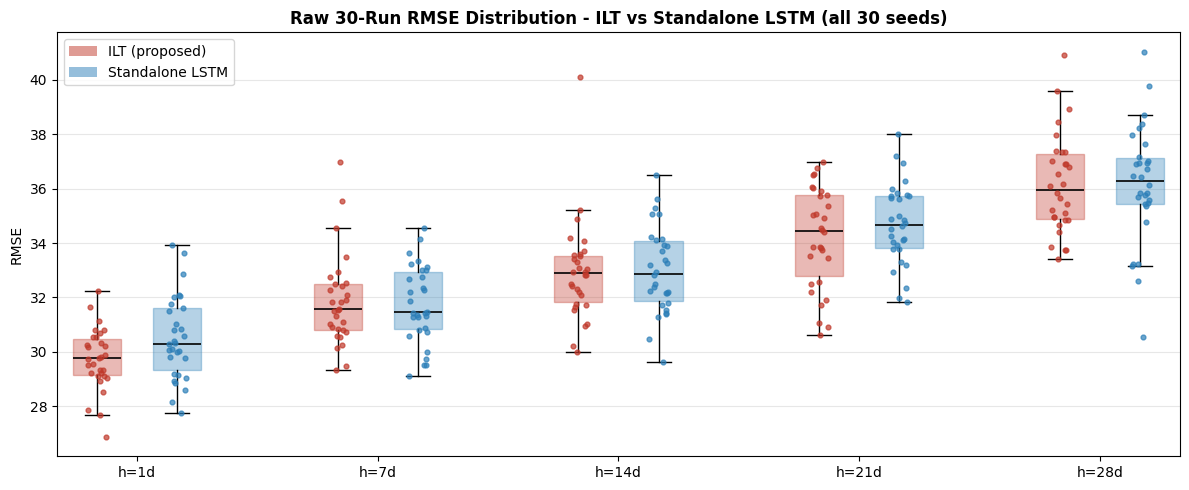

In [7]:
# --- Raw 30-run RMSE distribution across horizons (ILT vs Standalone LSTM) ---
# Box = quartiles, dots = each of the 30 individual seeds. Shows the raw per-seed spread.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np, pandas as pd

# use the in-memory 30-run table if it exists (this run), else load the saved CSV
try:
    _df = rmse_table.copy()
except NameError:
    _df = pd.read_csv('metrics/full_reproduction_rmse_30run.csv')

horizons = ['1d', '7d', '14d', '21d', '28d']
ILT, LSTM = '#c0392b', '#2c7fb8'
fig, ax = plt.subplots(figsize=(12, 5))
data, positions, colors, xt = [], [], [], []
pos = 1
for h in horizons:
    for col, c in [(f'ILT_h{h}', ILT), (f'Standalone LSTM_h{h}', LSTM)]:
        data.append(_df[col].values); positions.append(pos); colors.append(c); pos += 1
    xt.append(pos - 1.5); pos += 1
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                showfliers=False, medianprops=dict(color='black', linewidth=1.2))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.35); patch.set_edgecolor(c)
rng = np.random.default_rng(0)
for vals, p, c in zip(data, positions, colors):
    ax.scatter(p + rng.uniform(-0.12, 0.12, len(vals)), vals, s=12, color=c, alpha=0.7, zorder=3)
ax.set_xticks(xt); ax.set_xticklabels([f'h={h}' for h in horizons])
ax.set_ylabel('RMSE'); ax.set_axisbelow(True); ax.grid(axis='y', alpha=0.3)
ax.set_title('Raw 30-Run RMSE Distribution - ILT vs Standalone LSTM (all 30 seeds)', fontweight='bold')
ax.legend(handles=[Patch(facecolor=ILT, alpha=0.5, label='ILT (proposed)'),
                   Patch(facecolor=LSTM, alpha=0.5, label='Standalone LSTM')], loc='upper left')
plt.tight_layout()
plt.savefig('plots/raw_30run_rmse_distribution.png', dpi=170, bbox_inches='tight')
plt.show()


## Genuine statistical test — H2 (ILT vs Standalone LSTM) at every horizon

In [8]:
from scipy import stats

print("="*90)
print("  H2: Is ILT significantly better than Standalone LSTM? (paired by seed, n=30)")
print("="*90)
h2_summary = []
for h in HORIZONS:
    ilt = np.array(results[h]['ILT']['rmse'])
    lstm = np.array(results[h]['Standalone LSTM']['rmse'])
    diff = ilt - lstm
    sh_stat, sh_p = stats.shapiro(diff)
    t_stat, t_p = stats.ttest_rel(ilt, lstm)
    w_stat, w_p = stats.wilcoxon(ilt, lstm)
    dz = diff.mean() / diff.std(ddof=1)
    wins = int((ilt < lstm).sum())
    sig = '✅ SIGNIFICANT' if min(t_p, w_p) < 0.05 else '❌ not significant'
    h2_summary.append({'Horizon': f'h={h}d', 'ILT_mean': ilt.mean(), 'LSTM_mean': lstm.mean(),
                        'ILT_wins': f'{wins}/{N_SEEDS}', 'Shapiro_p': sh_p, 'paired_t_p': t_p,
                        'Wilcoxon_p': w_p, 'Cohens_d': dz, 'Verdict': sig})
    print(f"h={h:>2}d: ILT={ilt.mean():.2f}, LSTM={lstm.mean():.2f}, wins={wins}/{N_SEEDS}, "
          f"t_p={t_p:.4f}, wilcoxon_p={w_p:.4f}, d={dz:.3f}  {sig}")

h2_df = pd.DataFrame(h2_summary)
h2_df.to_csv('metrics/full_reproduction_h2_test.csv', index=False)
print("\n✅ Saved metrics/full_reproduction_h2_test.csv")
print("\nNOTE: Shapiro-Wilk p-value tells you whether to trust the paired t-test (p>0.05 = normal,")
print("      t-test OK) or whether to rely on Wilcoxon instead (p<0.05 = non-normal, use Wilcoxon).")


  H2: Is ILT significantly better than Standalone LSTM? (paired by seed, n=30)
h= 1d: ILT=29.73, LSTM=30.50, wins=17/30, t_p=0.0459, wilcoxon_p=0.1094, d=-0.381  ✅ SIGNIFICANT
h= 7d: ILT=31.84, LSTM=31.75, wins=15/30, t_p=0.8358, wilcoxon_p=0.9677, d=0.038  ❌ not significant
h=14d: ILT=32.92, LSTM=33.00, wins=15/30, t_p=0.8571, wilcoxon_p=0.7303, d=-0.033  ❌ not significant
h=21d: ILT=34.19, LSTM=34.70, wins=17/30, t_p=0.2590, wilcoxon_p=0.2710, d=-0.210  ❌ not significant
h=28d: ILT=36.17, LSTM=36.17, wins=14/30, t_p=0.9991, wilcoxon_p=0.8872, d=0.000  ❌ not significant

✅ Saved metrics/full_reproduction_h2_test.csv

NOTE: Shapiro-Wilk p-value tells you whether to trust the paired t-test (p>0.05 = normal,
      t-test OK) or whether to rely on Wilcoxon instead (p<0.05 = non-normal, use Wilcoxon).


## Ensemble check at every horizon (bonus — averaging the 30 predictions per model)

In [9]:
from sklearn.metrics import mean_squared_error

print("="*90)
print("  ENSEMBLE (30-model average) RMSE comparison — every horizon")
print("="*90)
ens_summary = []
for h in HORIZONS:
    y_true = seq_cache[h]['y_te_raw']
    ilt_preds = np.array(results[h]['ILT']['preds'])
    lstm_preds = np.array(results[h]['Standalone LSTM']['preds'])
    ilt_ens = ilt_preds.mean(axis=0)
    lstm_ens = lstm_preds.mean(axis=0)
    ilt_ens_rmse = np.sqrt(mean_squared_error(y_true, ilt_ens))
    lstm_ens_rmse = np.sqrt(mean_squared_error(y_true, lstm_ens))

    ilt_sq_err = (y_true - ilt_ens)**2
    lstm_sq_err = (y_true - lstm_ens)**2
    t_stat, t_p = stats.ttest_rel(ilt_sq_err, lstm_sq_err)
    w_stat, w_p = stats.wilcoxon(ilt_sq_err, lstm_sq_err)

    pct_diff = (lstm_ens_rmse - ilt_ens_rmse) / lstm_ens_rmse * 100
    sig = '✅ SIGNIFICANT' if min(t_p, w_p) < 0.05 else '❌ not significant'
    ens_summary.append({'Horizon': f'h={h}d', 'ILT_ensemble_RMSE': ilt_ens_rmse,
                         'LSTM_ensemble_RMSE': lstm_ens_rmse, 'Pct_diff': pct_diff,
                         'paired_t_p': t_p, 'Wilcoxon_p': w_p, 'Verdict': sig})
    print(f"h={h:>2}d: ILT_ens={ilt_ens_rmse:.2f}, LSTM_ens={lstm_ens_rmse:.2f}, "
          f"diff={pct_diff:+.2f}%, t_p={t_p:.5f}, wilcoxon_p={w_p:.5f}  {sig}")

ens_df = pd.DataFrame(ens_summary)
ens_df.to_csv('metrics/full_reproduction_ensemble_test.csv', index=False)
print("\n✅ Saved metrics/full_reproduction_ensemble_test.csv")


  ENSEMBLE (30-model average) RMSE comparison — every horizon
h= 1d: ILT_ens=29.30, LSTM_ens=30.26, diff=+3.17%, t_p=0.00000, wilcoxon_p=0.00000  ✅ SIGNIFICANT
h= 7d: ILT_ens=31.43, LSTM_ens=31.40, diff=-0.11%, t_p=0.75170, wilcoxon_p=0.00000  ✅ SIGNIFICANT
h=14d: ILT_ens=32.35, LSTM_ens=32.63, diff=+0.87%, t_p=0.04560, wilcoxon_p=0.00901  ✅ SIGNIFICANT
h=21d: ILT_ens=33.73, LSTM_ens=34.31, diff=+1.68%, t_p=0.00000, wilcoxon_p=0.00000  ✅ SIGNIFICANT
h=28d: ILT_ens=35.62, LSTM_ens=35.66, diff=+0.12%, t_p=0.73528, wilcoxon_p=0.01741  ✅ SIGNIFICANT

✅ Saved metrics/full_reproduction_ensemble_test.csv


In [10]:
print("="*90)
print("  FINAL SUMMARY")
print("="*90)
print("\nPer-run H2 test (does a SINGLE trained instance of ILT reliably beat Standalone LSTM?):")
print(h2_df[['Horizon','ILT_mean','LSTM_mean','ILT_wins','paired_t_p','Wilcoxon_p','Verdict']].to_string(index=False))
print("\nEnsemble H2 test (does the AVERAGE of 30 trained instances reliably beat the average LSTM?):")
print(ens_df[['Horizon','ILT_ensemble_RMSE','LSTM_ensemble_RMSE','Pct_diff','Verdict']].to_string(index=False))

print("\n📁 All files saved to metrics/:")
print("   full_reproduction_checkpoint.pkl   (raw predictions + metrics, for resuming/reuse)")
print("   full_reproduction_rmse_30run.csv")
print("   full_reproduction_mae_30run.csv")
print("   full_reproduction_r2_30run.csv")
print("   full_reproduction_h2_test.csv")
print("   full_reproduction_ensemble_test.csv")


  FINAL SUMMARY

Per-run H2 test (does a SINGLE trained instance of ILT reliably beat Standalone LSTM?):
Horizon  ILT_mean  LSTM_mean ILT_wins  paired_t_p  Wilcoxon_p           Verdict
   h=1d 29.727212  30.504432    17/30    0.045878    0.109432     ✅ SIGNIFICANT
   h=7d 31.843252  31.750978    15/30    0.835848    0.967674 ❌ not significant
  h=14d 32.919628  32.998753    15/30    0.857078    0.730342 ❌ not significant
  h=21d 34.193516  34.696923    17/30    0.259014    0.271006 ❌ not significant
  h=28d 36.166333  36.165666    14/30    0.999065    0.887195 ❌ not significant

Ensemble H2 test (does the AVERAGE of 30 trained instances reliably beat the average LSTM?):
Horizon  ILT_ensemble_RMSE  LSTM_ensemble_RMSE  Pct_diff       Verdict
   h=1d          29.298274           30.256871  3.168198 ✅ SIGNIFICANT
   h=7d          31.434981           31.400569 -0.109592 ✅ SIGNIFICANT
  h=14d          32.347730           32.631972  0.871053 ✅ SIGNIFICANT
  h=21d          33.729958           